# Task 03 - Decision Tree Classifier for Bank Marketing Dataset

## Objective
Build a Decision Tree Classifier to predict whether a customer will subscribe to a bank deposit based on demographic and behavioral data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

Saving bank.csv to bank.csv


In [4]:
df = pd.read_csv('bank.csv')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
print(df.shape)

print(df.columns)

df.info()

(11162, 17)
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64

In [6]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [7]:
X = df.drop('deposit', axis=1)

y = df['deposit']

print(X.shape)
print(y.shape)

(11162, 16)
(11162,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [9]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7707120465741155


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.76      0.78      1166
           1       0.75      0.78      0.76      1067

    accuracy                           0.77      2233
   macro avg       0.77      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



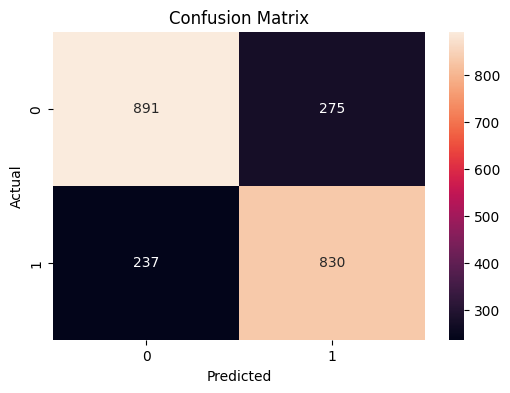

In [13]:
fig = plt.figure(figsize=(6,4))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

fig.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

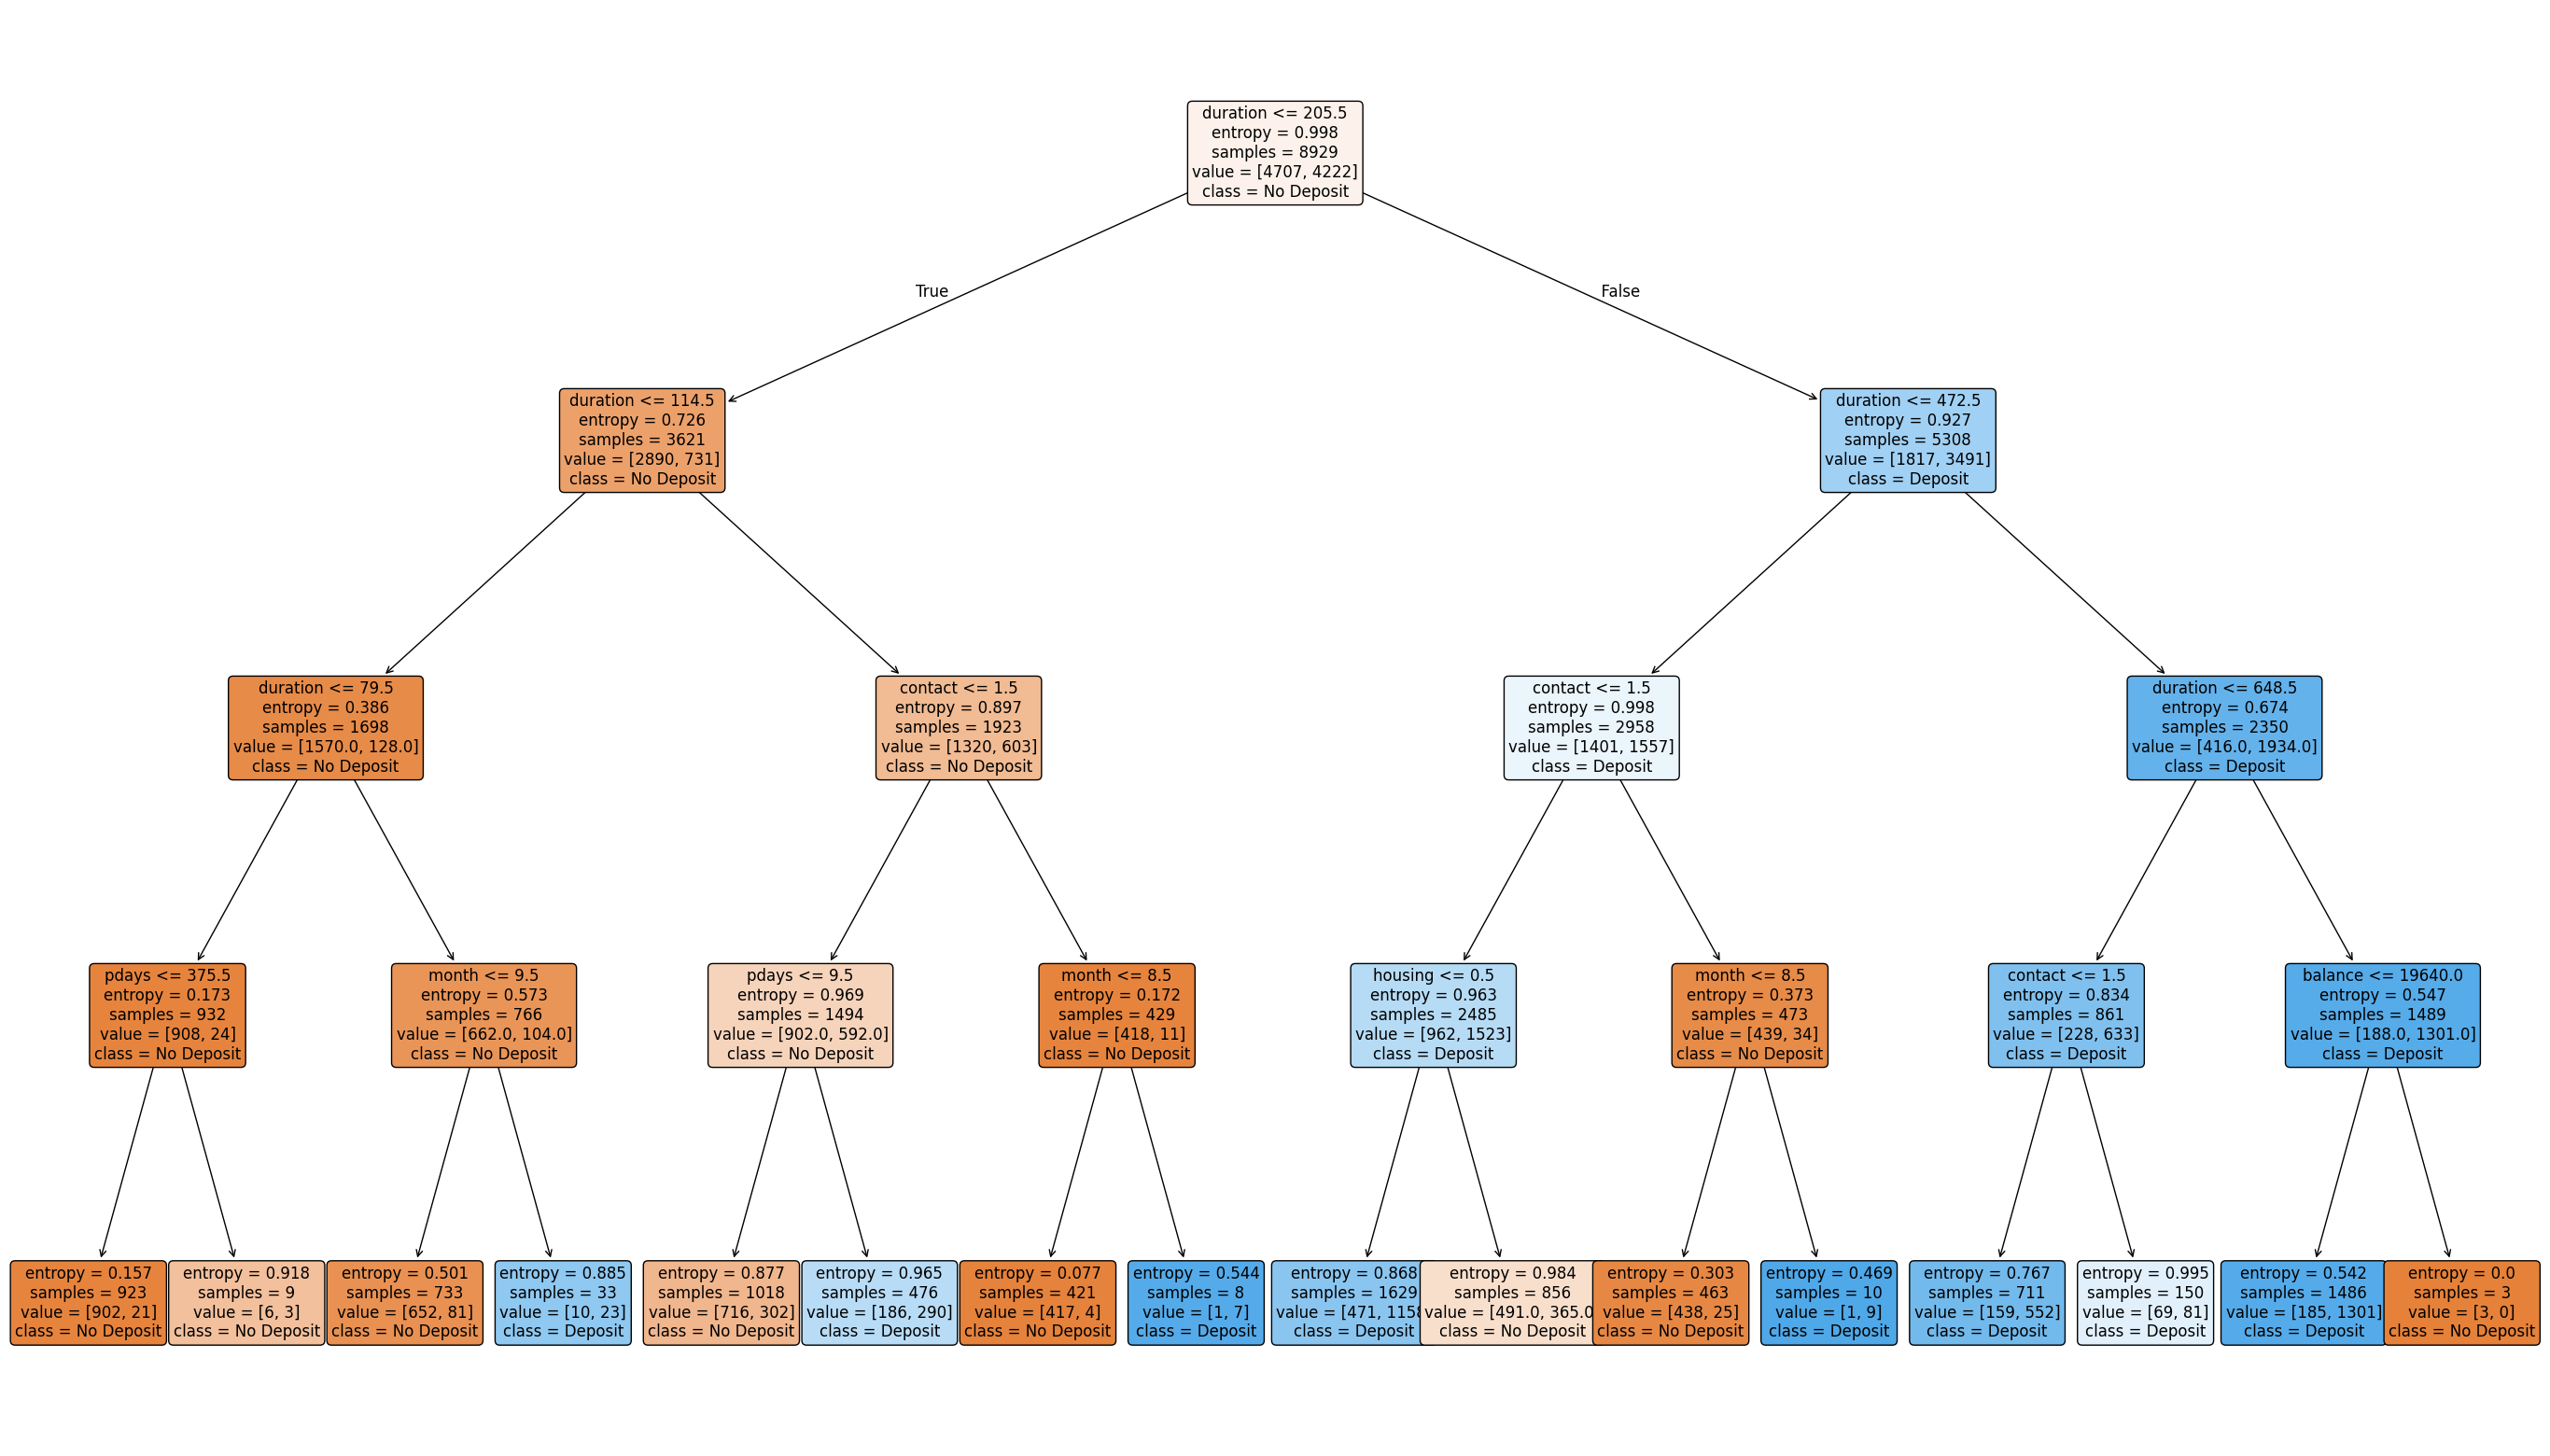

In [14]:
fig = plt.figure(figsize=(35,20))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Deposit', 'Deposit'],
    filled=True,
    rounded=True,
    fontsize=12
)

fig.savefig('decision_tree.png', dpi=300, bbox_inches='tight')

plt.show()

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

      Feature  Importance
11   duration    0.684060
8     contact    0.198935
6     housing    0.044611
10      month    0.035957
13      pdays    0.033509
5     balance    0.002927
0         age    0.000000
1         job    0.000000
7        loan    0.000000
4     default    0.000000
2     marital    0.000000
3   education    0.000000
9         day    0.000000
12   campaign    0.000000
14   previous    0.000000
15   poutcome    0.000000


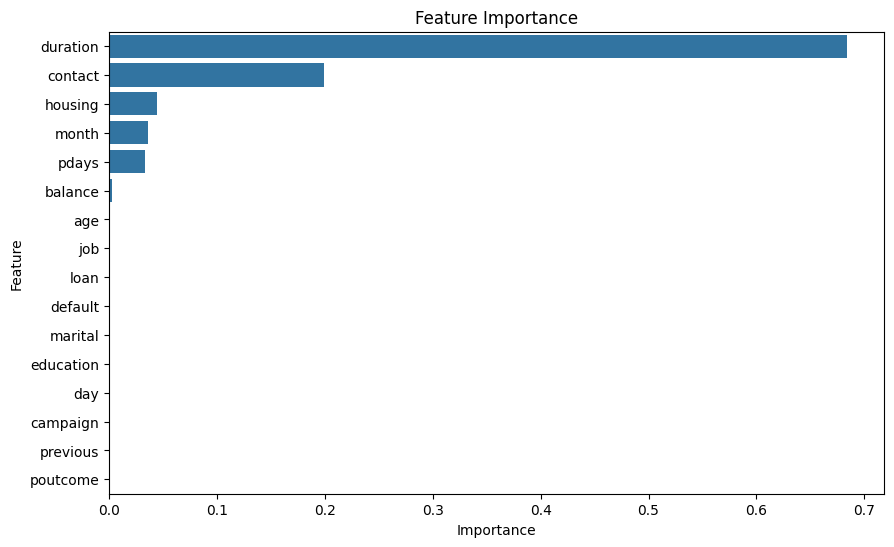

In [16]:
fig = plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

fig.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

# Findings

1. Loaded the Bank Marketing Dataset.
2. Performed preprocessing and label encoding.
3. Built a Decision Tree Classifier.
4. Evaluated the model using Accuracy Score and Confusion Matrix.
5. Visualized the Decision Tree.
6. Analyzed Feature Importance.

# Conclusion

The Decision Tree model successfully predicts customer deposits using demographic and behavioral data. Important factors influencing customer decisions were identified through feature importance analysis.